### Import Libraries

In [26]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import math
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import os
if not os.path.exists('artifacts/images'):
    os.makedirs('artifacts/images')

### Load and Inspect the dataset

In [27]:
df = pd.read_csv('../data/raw/Fraud_Data.csv')

In [28]:
display(df.head())
display(df.info())
display(df.isnull().sum())

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


None

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [29]:
display(df.isnull().sum())

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

### Outlier Identification

#### Sigma Rule

In [30]:
def find_anomaly(data):
    mean = data.mean()
    std = data.std()

    upper_bound = mean + (3 * std)
    lower_bound = mean - (3 * std)

    return (data > upper_bound) | (data < lower_bound)

num_cols = ['purchase_value', 'age']

for col in num_cols:
    n_outliers = find_anomaly(df[col]).sum()
    n_outlier_percentage = round(n_outliers / len(df),3)
    print(f"{col} : {n_outliers} outliers ({n_outlier_percentage} %)")

purchase_value : 865 outliers (0.006 %)
age : 553 outliers (0.004 %)


#### IQR Method

In [31]:
def find_anomaly(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3 - Q1 

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR 

    return (data > upper_bound) | (data < lower_bound)
for col in num_cols:
    n_outliers = find_anomaly(df[col]).sum()
    n_outlier_percentage = round(n_outliers / len(df), 3)
    print(f"{col} : {n_outliers} outliers ({n_outlier_percentage} %)")

purchase_value : 1067 outliers (0.007 %)
age : 776 outliers (0.005 %)


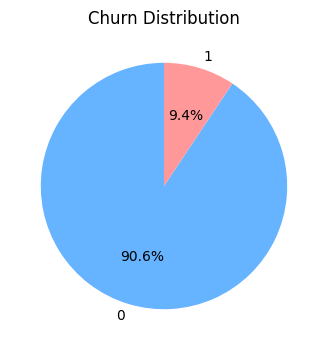

In [32]:
plt.figure(figsize=(4, 4))
df['class'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Churn Distribution')
plt.ylabel('')
plt.savefig('../artifacts/images/class.png')
plt.show()

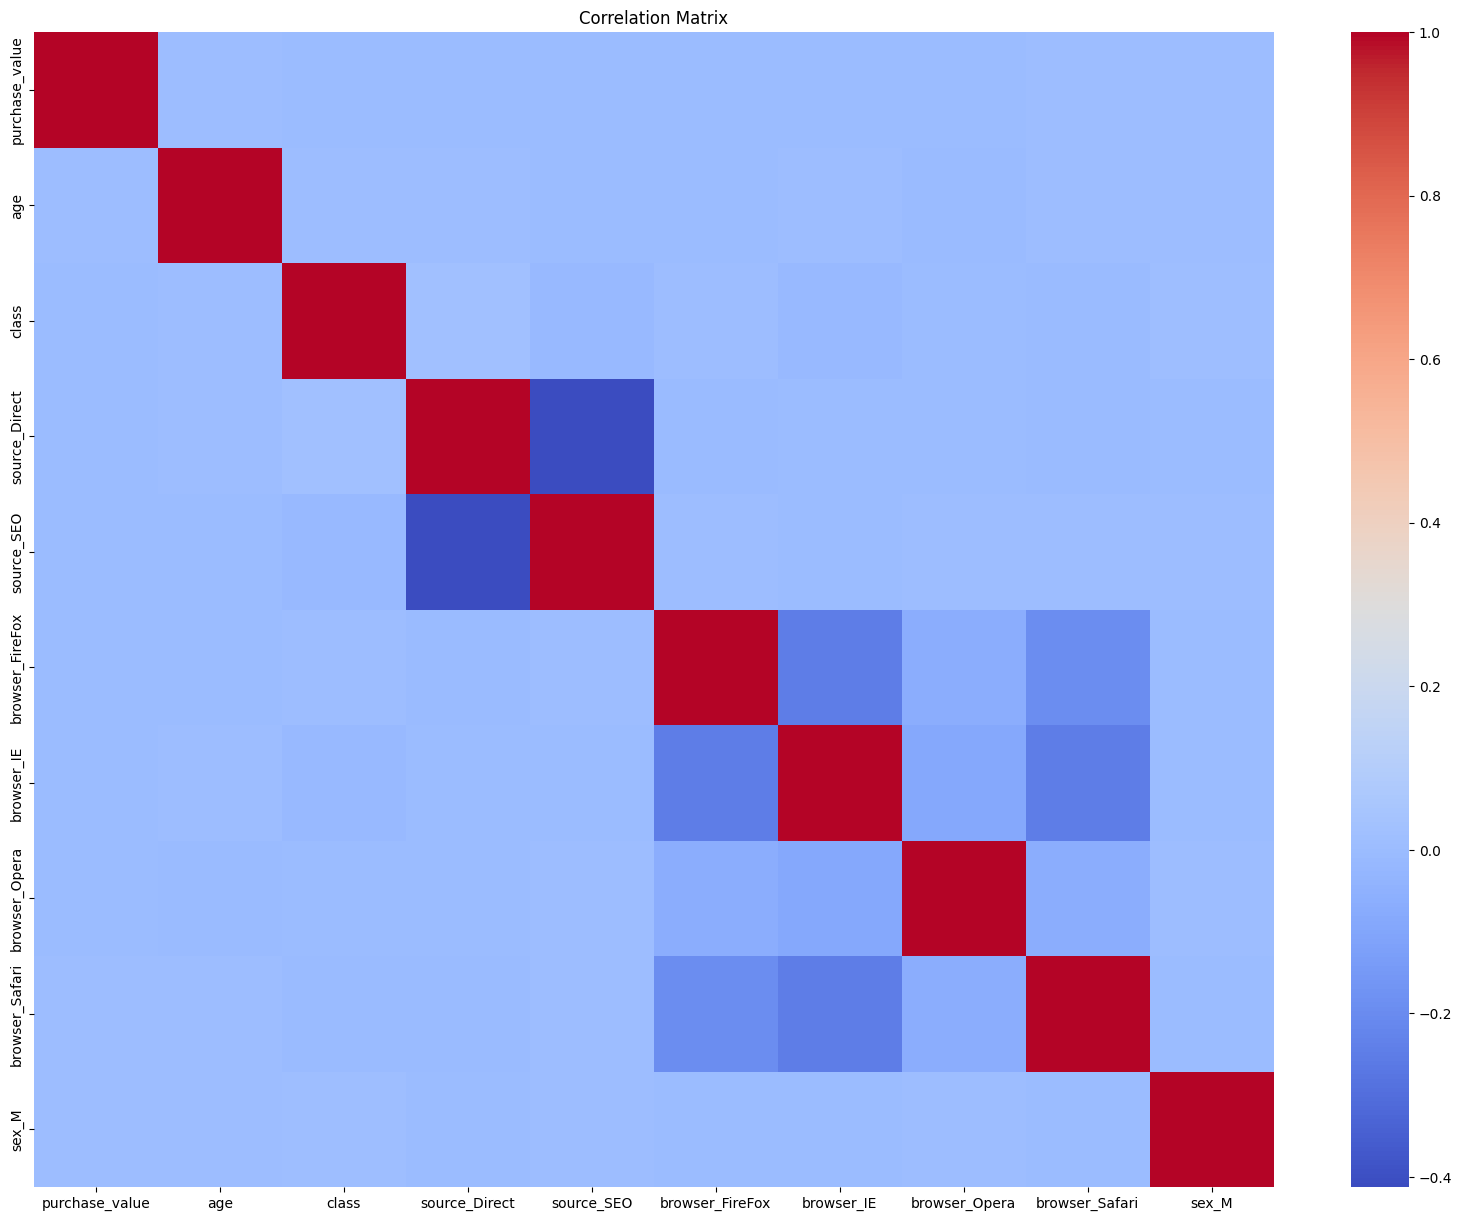

class              1.000000
source_Direct      0.020285
sex_M              0.007639
age                0.006624
browser_FireFox    0.002299
purchase_value     0.001011
browser_Opera     -0.002395
browser_Safari    -0.005222
source_SEO        -0.012251
browser_IE        -0.013363
Name: class, dtype: float64
class              1.000000
source_Direct      0.020285
sex_M              0.007639
age                0.006624
browser_FireFox    0.002299
purchase_value     0.001011
browser_Opera     -0.002395
browser_Safari    -0.005222
source_SEO        -0.012251
browser_IE        -0.013363
Name: class, dtype: float64


In [34]:
# Convert class to numeric for correlation
df_corr = df.copy()

# Drop very high-cardinality / non-numeric columns before one-hot encoding
drop_cols = ['user_id', 'device_id', 'ip_address', 'signup_time', 'purchase_time']
df_corr = df_corr.drop(columns=drop_cols)

# One-hot encode for full correlation matrix (with fewer columns)
df_corr = pd.get_dummies(df_corr, drop_first=True)

plt.figure(figsize=(20, 15))
sns.heatmap(df_corr.corr(), annot=False, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.savefig('../artifacts/images/correlation_matrix.png')
plt.show()

# Top correlations with Churn
churn_corr = df_corr.corr()['class'].sort_values(ascending=False)
print(churn_corr.head(10))
print(churn_corr.tail(10))